Nama : Fadhlan Nur Rachman
NIM : 2802491690

In [74]:
# Import Library and Data

from Bio import SeqIO
from collections import Counter
from Bio.SeqUtils import gc_fraction, MeltingTemp, molecular_weight
from Bio.pairwise2 import format_alignment, align
import matplotlib.pyplot as plt
from Levenshtein import distance


# read FASTA file
seqA = SeqIO.read('dataset/a.fasta', 'fasta').seq
seqB = SeqIO.read('dataset/b.fasta', 'fasta').seq

print("Seq A: ",seqA)
print("Seq B: ",seqB)

Seq A:  GCTTTCGCCGCCTGGGAGCCGTCCGGCGCAGCAGTTTCTAGGTCCCCACTGTCCCCGCCGTCCCGCCCCTTCGCGTCCCGGGAACCGGCTGGCTTCCGAGCCGCACTCGCCGATCCTCCAGGCATGCCCCGCTACGAGCTGGCTTTAATCCTGAAAGCCATGCAGCGGCCAGAGACTGCTGCTACTTTGAAACGTACGATAGAGGCCCTGATGGACAGAGGAGCAATAGTGAGGGACTTGGAAAACCTGGGTGAACGAGCGCTTCCTTATAGGATCTCTGCCCACAGTCAGCAGCACAACAGAGGCGGGTATTTCTTGGTGGATTTTTATGCACCCACCGCAGCTGTTGAAAGCATGGTGGAGCACTTGTCTCGAGATATAGATGTGATTAGAGGGAATATTGTCAAACACCCTCTGACCCAGGAACTAAAAGAATGTGAAGGGATTGTCCCAGTCCCACTCGCAGAAAAATTATATTCCACAAAGAAGAGGAAGAAGTGAGAAGATTCGCCAGATTTTAGCCTTATATGTAATTCCTTCACATTTGGGCAGCATGGACGAGAAGGAAGAATTTGCAAGTTTGGCCTTTATATAAGCATGTGTTGCAGGTGCTGTTTGATTTTTCTAAGGTATTTTTAGCCCTTGATCCCCTTTGCTTGCGAGAGGTGGGGAACTGCTCACTGACAGCTTCTCTGTAACCTGCAGTACCAGTGGATCGTTCTTGATTTTGTTTTCATTAGTGTCATTTCTTTGTCATTGAGGACTTTTCCCCTTACAACAGTAACACCATTTTTTGAAGAGCAAAACTTATAATACCTCCTGGGATTGTGAGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
Seq B:  ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGG

# 1. Sequence Manipulation

In [60]:
# a. Find and display the length of Sequence A and B. 

len_a = len(seqA)
len_b = len(seqB)

print("Seq A: ",len_a)
print("Seq B: ",len_b)
print("Total length A dan B:", len_a + len_b)

Seq A:  931
Seq B:  810
Total length A dan B: 1741


In [61]:
# b. Find and display which index the first time codon (ATC) appears in both Sequence A and B. 

idxatc_a = seqA.index('ATC')
idxatc_b = seqB.index('ATC')

print("first time codon (ATC) in seq A:", idxatc_a)
print("first time codon (ATC) in seq B:", idxatc_b)

first time codon (ATC) in seq A: 112
first time codon (ATC) in seq B: 21


In [62]:
# c. Take the first 15 nucleotides from Sequence A, and the last 35 nucleotides from Sequence B. 
# Then combine the sequences and reverse it to a new sequence, Sequence C.

slice_seqA = seqA[:15] # 15 first seqA
slice_seqB = seqB[35:] # 35 last seqB
combine = slice_seqA + slice_seqB
seqC = combine[::-1] # reverese

print(slice_seqA)
print(slice_seqB)
print("combine A and B: ", combine)
print("Sequence C: ",seqC)





GCTTTCGCCGCCTGG
AGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
combine A and B:  GCTTTCGCCGCCTGGAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCA

# 2. Sequence Analysis & Plotting 

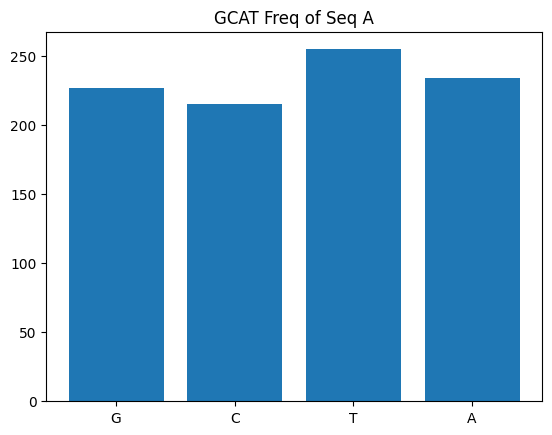

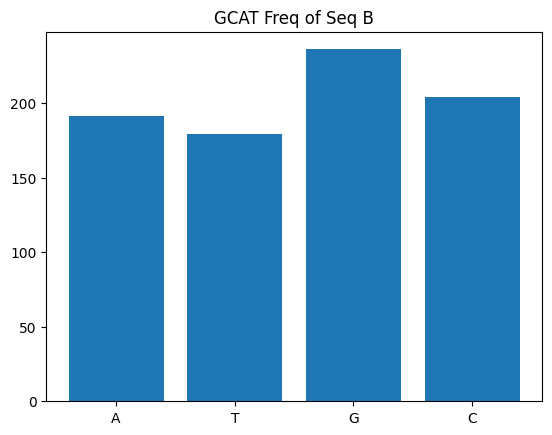

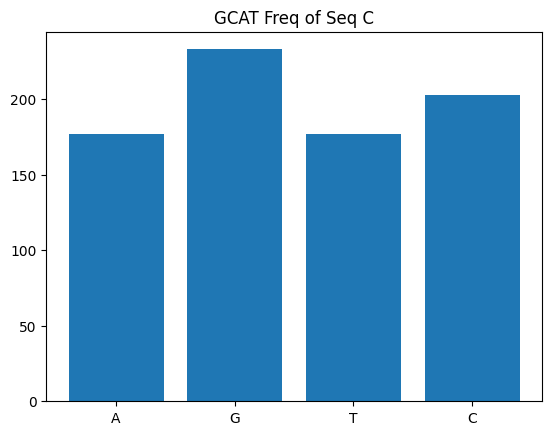

In [63]:
# a. Determine and display the nucleotides base (A, C, G, T) frequency for Sequence A, B, and C with a chart using matplotlib library. 

counter_a = Counter(seqA)
counter_b = Counter(seqB)
counter_c = Counter(seqC)

plt.bar(counter_a.keys(), counter_a.values())
plt.title("GCAT Freq of Seq A")
plt.show()

plt.bar(counter_b.keys(), counter_b.values())
plt.title("GCAT Freq of Seq B")
plt.show()

plt.bar(counter_c.keys(), counter_c.values())
plt.title("GCAT Freq of Seq C")
plt.show()

In [64]:
# b. Determine and display the GC & AT content percentage for Sequence A, B, and C. 

gc_a = gc_fraction(seqA)*100.
gc_b = gc_fraction(seqB)*100
gc_c = gc_fraction(seqC)*100

print(f"GC content of seqA: {gc_a:.2f}%")
print(f"AT content of seqA: {100-gc_a:.2f}%")
print()
print(f"GC content of seqB: {gc_b:.2f}%")
print(f"AT content of seqB: {100-gc_b:.2f}%")
print()
print(f"GC content of seqC: {gc_c:.2f}%")
print(f"AT content of seqC: {100-gc_c:.2f}%")
print()

GC content of seqA: 47.48%
AT content of seqA: 52.52%

GC content of seqB: 54.32%
AT content of seqB: 45.68%

GC content of seqC: 55.19%
AT content of seqC: 44.81%



In [65]:
# c. Determine and display the melting temperature for Sequence A, B, and C (using built-in Wallace, Nearest Neighbor, and GC Method). 

mel_temp_a = MeltingTemp.Tm_Wallace(seqA)
mel_temp_b = MeltingTemp.Tm_Wallace(seqB)
mel_temp_c = MeltingTemp.Tm_Wallace(seqC)

print("Melting Temperature Seq A: ", mel_temp_a)
print("Melting Temperature Seq B: ", mel_temp_b)
print("Melting Temperature Seq C: ", mel_temp_c)


Melting Temperature Seq A:  2746.0
Melting Temperature Seq B:  2500.0
Melting Temperature Seq C:  2452.0


In [66]:
# d. Determine and display the molecular weight for Sequence A, B, and C.

mol_weight_a = molecular_weight(seqA)
mol_weight_b = molecular_weight(seqB)
mol_weight_c = molecular_weight(seqC)

print("Molecular Weight of Seq A: ", mol_weight_a)
print("Molecular Weight of Seq B: ", mol_weight_b)
print("Molecular Weight of Seq C: ", mol_weight_c)

Molecular Weight of Seq A:  287781.4286000008
Molecular Weight of Seq B:  250976.71919999958
Molecular Weight of Seq C:  244706.64229999963


# 3. DNA & mRNA Protein Synthesis

In [67]:
# a. Transcribe and display the DNA Sequence A, B, and C into mRNA Sequences. 
mRNA_a = seqA.transcribe()
mRNA_b = seqB.transcribe()
mRNA_c = seqC.transcribe()

print("Seq A : ", seqA)
print("mRNA A: ", mRNA_a)
print()
print("Seq B : ", seqB)
print("mRNA B: ", mRNA_b)
print()
print("Seq C : ", seqC)
print("mRNA C: ", mRNA_c)




Seq A :  GCTTTCGCCGCCTGGGAGCCGTCCGGCGCAGCAGTTTCTAGGTCCCCACTGTCCCCGCCGTCCCGCCCCTTCGCGTCCCGGGAACCGGCTGGCTTCCGAGCCGCACTCGCCGATCCTCCAGGCATGCCCCGCTACGAGCTGGCTTTAATCCTGAAAGCCATGCAGCGGCCAGAGACTGCTGCTACTTTGAAACGTACGATAGAGGCCCTGATGGACAGAGGAGCAATAGTGAGGGACTTGGAAAACCTGGGTGAACGAGCGCTTCCTTATAGGATCTCTGCCCACAGTCAGCAGCACAACAGAGGCGGGTATTTCTTGGTGGATTTTTATGCACCCACCGCAGCTGTTGAAAGCATGGTGGAGCACTTGTCTCGAGATATAGATGTGATTAGAGGGAATATTGTCAAACACCCTCTGACCCAGGAACTAAAAGAATGTGAAGGGATTGTCCCAGTCCCACTCGCAGAAAAATTATATTCCACAAAGAAGAGGAAGAAGTGAGAAGATTCGCCAGATTTTAGCCTTATATGTAATTCCTTCACATTTGGGCAGCATGGACGAGAAGGAAGAATTTGCAAGTTTGGCCTTTATATAAGCATGTGTTGCAGGTGCTGTTTGATTTTTCTAAGGTATTTTTAGCCCTTGATCCCCTTTGCTTGCGAGAGGTGGGGAACTGCTCACTGACAGCTTCTCTGTAACCTGCAGTACCAGTGGATCGTTCTTGATTTTGTTTTCATTAGTGTCATTTCTTTGTCATTGAGGACTTTTCCCCTTACAACAGTAACACCATTTTTTGAAGAGCAAAACTTATAATACCTCCTGGGATTGTGAGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
mRNA A:  GCUUUCGCCGCCUGGGAGCCGUCCGGCGCAGCAGUUUCUAGGUCCCCACU

In [68]:
# b. Translate and display the mRNA Sequence A, B, and C into amino acids sequences. 

aminoacids_a = mRNA_a.translate()
aminoacids_b = mRNA_b.translate()
aminoacids_c = mRNA_c.translate()

print("Amino Acid of Seq A: ", aminoacids_a)
print("Amino Acid of Seq B: ", aminoacids_b)
print("Amino Acid of Seq C: ", aminoacids_c)

Amino Acid of Seq A:  AFAAWEPSGAAVSRSPLSPPSRPFASREPAGFRAALADPPGMPRYELALILKAMQRPETAATLKRTIEALMDRGAIVRDLENLGERALPYRISAHSQQHNRGGYFLVDFYAPTAAVESMVEHLSRDIDVIRGNIVKHPLTQELKECEGIVPVPLAEKLYSTKKRKK*EDSPDFSLICNSFTFGQHGREGRICKFGLYISMCCRCCLIFLRYF*PLIPFACERWGTAH*QLLCNLQYQWIVLDFVFISVISLSLRTFPLTTVTPFFEEQNL*YLLGL*ASHSACVTMWK*KLTTNVLYGQLLL*VINLIVG
Amino Acid of Seq B:  MTHKATEILTGKVMQKSVLITGCSSGIGLESALELKRQGFHVLAGCRKPDDVERMNSMGFTGVLIDLDSPESVDRAADEVIALTDNCLYGIFNNAGFGMYGPLSTISRAQMEQQFSANFFGAHQLTMRLLPAMLPHGEGRIVMTSSVMGLISTPGRGAYAASKYALEAWSDALRMELRHSGIKVSLIEPGPIRTRFTDNVNQTQSDKPVENPGIAARFTLGPEAVVDKVRHAFISEKPKMRYPVTLVTWAVMVLKRLLPGRVMDKILQG*
Amino Acid of Seq C:  SGDVIKQVVRGAVVREFVVMAGPVVAVAYRVEAEERLFSYRMKQVVAKARVAFRPPLRP*KLTK**NADQLQQPLRSCLPWPKLVRLKLRRHRVEVRVT*TGAEVAYK*PAHSRCWAAPLIRVVATTVVLCGKWHAIVAPIVRVPLDHTRLFQPPFDDKVDACRLPPFPRYVRLRP*QFLGYVC**PVPLVEQPTR*L*KTT*V*LVVRPFRVRQVREL**AKGRWTVVYFWDRKIKLARKVRLR*PCRPLILAKNVLRSAAF


/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


# 4. 4.	Sequence Alignment & Similarities

In [69]:
# a. Perform local alignment pairwise using the default scoring parameters (clue: use localxx) between Sequence A and Sequence “ATCGTACGGTACCGTAA” and display the alignments’ score. Perform another local alignment using custom scoring (clue: use localms)

print("Local Alignment")
local_alignment_a = align.localxx(seqA, "ATCGTACGGTACCGTAA")
for alignment in local_alignment_a:
    print(format_alignment(*alignment))

Local Alignment
843 AGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |       |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A-------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

839 ATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |           |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A-----------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

835 AGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |               |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A---------------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

831 AGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATG

In [70]:
print("Local Alignment Custom")
local_alignment_a_custom = align.localms(seqA, "ATCGTACGGTACCGTAA", 2, -1, -2, -0.5)
for alignment in local_alignment_a_custom:
    print(format_alignment(*alignment))

Local Alignment Custom
191 AACGTACGATAGAGGCCCTGA
    |.||||||.||    ||.|.|
  1 ATCGTACGGTA----CCGTAA
  Score=18.5



In [71]:
# b. Perform global alignment pairwise using the default scoring parameters (clue: use globalxx) between Sequence B and Sequence “GGTACCGTAGCTAGGCTAATCG” and display the alignments’ score. Perform another global alignment using custom scoring (clue: use globalms)
print("Global Alignment")
global_alignment_b_ = align.globalxx(seqB, "GGTACCGTAGCTAGGCTAATCG")
for alignment in global_alignment_b_:
    print(format_alignment(*alignment))

Global Alignment
ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
                                                                                                                                                                            

In [72]:
print("Global Alignment Custom")
global_alignment_b_custom = align.globalms(seqB, "GGTACCGTAGCTAGGCTAATCG", 2, -1, -2, -0.5)
for alignment in global_alignment_b_custom:
    print(format_alignment(*alignment))

Global Alignment Custom
ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
                              ||||                                                                                                                                   

In [75]:
# c. Find and display the Levenshtein distance between Sequence A and B

distance(seqA, seqB)

487